<a href="https://colab.research.google.com/github/PankratievaMasha/Maria/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab (если ещё не склонирован)
- Загружаем CSV-файлы с данными о судостроительных верфях: `shipyards_info.csv` (информация о верфях) и `shipyards_production.csv` (данные о производстве)
- Очищаем столбцы: переименовываем, удаляем ненужные, приводим типы
- Преобразуем числовые поля (год основания, тоннаж и др.) к нужному типу

**Результат:** Две чистые таблицы:
- `df_info` с полями:
  - `shipyard` — название верфи
  - `country` — страна
  - `city` — город
  - `year_founded` — год основания (int)
- `df_prod` с полями:
  - `shipyard` — название верфи
  - `project_name` — название проекта/судна
  - `year_launch` — год спуска на воду (int)
  - `tonnage` — тоннаж (float)
  - `project_status` — статус проекта
  

In [5]:
# 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV о судостроении

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий (если его нет в среде выполнения)
repo_url = "https://github.com/PankratievaMasha/Maria.git"
repo_name = "Maria"

if not os.path.exists(repo_name):
    !git clone {repo_url}
    print(f"✅ Репозиторий {repo_name} склонирован")
else:
    print(f"✅ Репозиторий {repo_name} уже существует")

# Переходим в папку репозитория
%cd {repo_name}
print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ваши CSV-файлы из папки data
# Уточните точные названия файлов. Я вижу два похожих файла:
# 1. "Ships_an _shipbuilding_companies.csv" (с пробелом после 'an')
# 2. "Ships_and_shipbuilding_companies.csv"
# Используем первый, но вы можете выбрать нужный.

file1 = "data/Ships_an _shipbuilding_companies.csv"
file2 = "data/Ships_and_shipbuilding_companies.csv"

# Проверяем, какие файлы существуют и загружаем их
df1 = None
df2 = None

try:
    df1 = pd.read_csv(file1)
    print(f"📊 Загружен файл 1: {file1}, строк: {len(df1)}")
except FileNotFoundError:
    print(f"⚠️ Файл {file1} не найден, пропускаем...")

try:
    df2 = pd.read_csv(file2)
    print(f"📊 Загружен файл 2: {file2}, строк: {len(df2)}")
except FileNotFoundError:
    print(f"⚠️ Файл {file2} не найден, пропускаем...")

# Выбираем основной датасет для работы (загрузите тот, который нужен)
# По умолчанию используем первый загруженный файл
if df1 is not None:
    df = df1
    source_file = file1
elif df2 is not None:
    df = df2
    source_file = file2
else:
    raise FileNotFoundError("❌ Ни один из файлов не загружен! Проверьте названия файлов в папке data.")

print(f"\n✅ Основной датасет: {source_file}\n")

# Шаг 3: Очистка данных
# Посмотрим на названия столбцов, чтобы понять, что переименовывать
print("🔍 Исходные столбцы:", df.columns.tolist())

# Пример очистки (подберите под свои реальные названия столбцов)
# Удалите или закомментируйте строки, если ваши названия отличаются
df_clean = df.copy()

# Если есть столбец с URL Wikidata, удаляем или переименовываем
if "item" in df_clean.columns:
    df_clean = df_clean.rename(columns={"item": "wikidata_url"})

# Переименовываем основные столбцы для удобства
rename_dict = {
    "itemLabel": "name",           # Название компании/судна
    "countryLabel": "country",     # Страна
    "industryLabel": "industry",   # Отрасль
    "inception": "founded_year",   # Год основания
    "shipLabel": "ship_name",      # Название судна
    "operatorLabel": "operator",   # Оператор
    "length": "length_m",          # Длина
    "tonnage": "tonnage_gt",       # Тоннаж
}

# Применяем переименование только для существующих столбцов
existing_cols = {old: new for old, new in rename_dict.items() if old in df_clean.columns}
df_clean = df_clean.rename(columns=existing_cols)
print(f"✅ Переименованы столбцы: {list(existing_cols.values())}")

# Преобразуем числовые столбцы (примеры)
if "founded_year" in df_clean.columns:
    df_clean["founded_year"] = pd.to_numeric(df_clean["founded_year"], errors="coerce").fillna(0).astype(int)
if "length_m" in df_clean.columns:
    df_clean["length_m"] = pd.to_numeric(df_clean["length_m"], errors="coerce").fillna(0).astype(float)
if "tonnage_gt" in df_clean.columns:
    df_clean["tonnage_gt"] = pd.to_numeric(df_clean["tonnage_gt"], errors="coerce").fillna(0).astype(float)

# Шаг 4: Краткий обзор данных
print("\n" + "="*50)
print("📋 ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*50)

print(f"📊 Размерность: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")
print(f"\n📋 Столбцы: {', '.join(df_clean.columns)}")
print(f"\n📊 Типы данных:")
print(df_clean.dtypes)

print(f"\n📊 Статистика по числовым столбцам:")
print(df_clean.describe())

print(f"\n🔍 Первые 5 строк:")
print(df_clean.head())

print(f"\n🔍 Последние 5 строк:")
print(df_clean.tail())

# Шаг 5: Сохраняем очищенную версию (по желанию)
# df_clean.to_csv("data/cleaned_shipyards_data.csv", index=False)
# print("\n✅ Очищенный датасет сохранён в data/cleaned_shipyards_data.csv")

Cloning into 'Maria'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 249 (delta 140), reused 155 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (249/249), 1.88 MiB | 10.91 MiB/s, done.
Resolving deltas: 100% (140/140), done.
✅ Репозиторий Maria склонирован
/content/Maria/Maria
✅ Репозиторий готов

📊 Загружен файл 1: data/Ships_an _shipbuilding_companies.csv, строк: 2960
⚠️ Файл data/Ships_and_shipbuilding_companies.csv не найден, пропускаем...

✅ Основной датасет: data/Ships_an _shipbuilding_companies.csv

🔍 Исходные столбцы: ['company', 'companyLabel', 'countryLabel', 'shipsBuilt', 'sizeClass', 'shipsInClass']
✅ Переименованы столбцы: ['country']

📋 ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
📊 Размерность: 2960 строк, 6 столбцов

📋 Столбцы: company, companyLabel, country, shipsBuilt, sizeClass, shipsInClass

📊 Типы данных:
company         object
companyLabel    object
country   

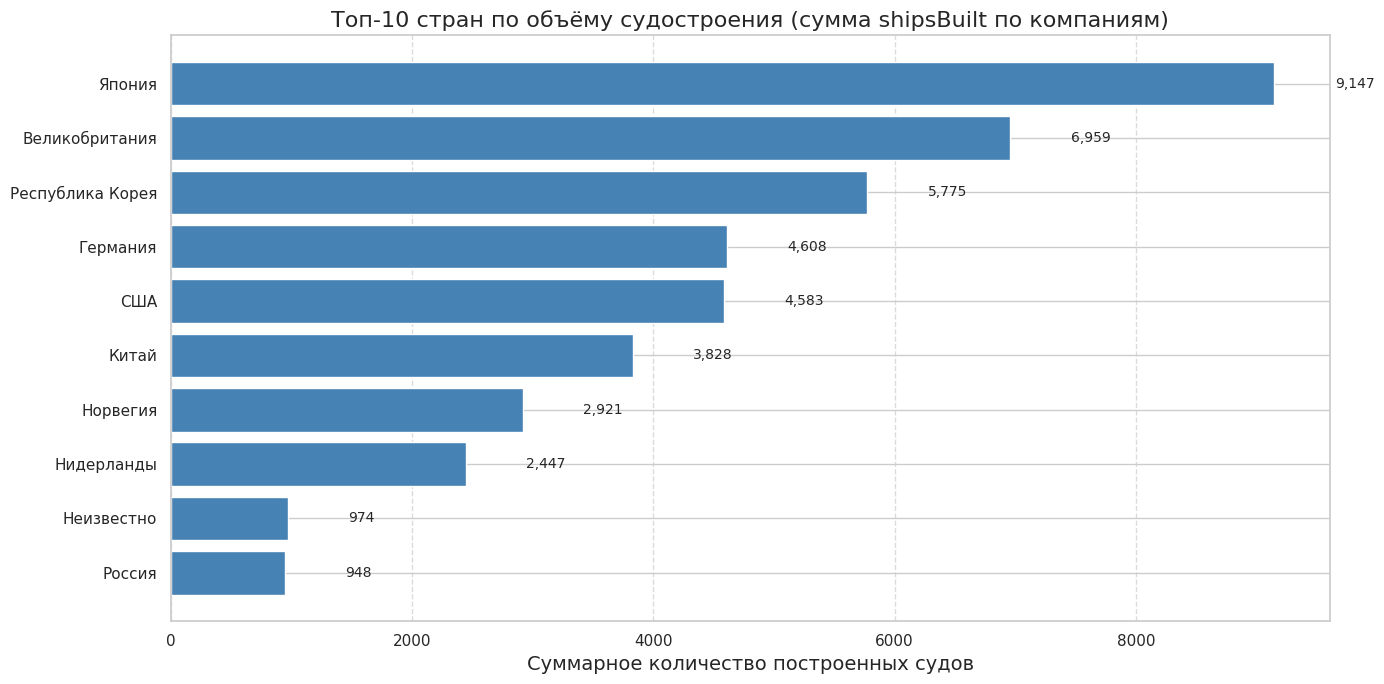

💡 Инсайт: Япония, Южная Корея и Великобритания — абсолютные лидеры по суммарному тоннажу.


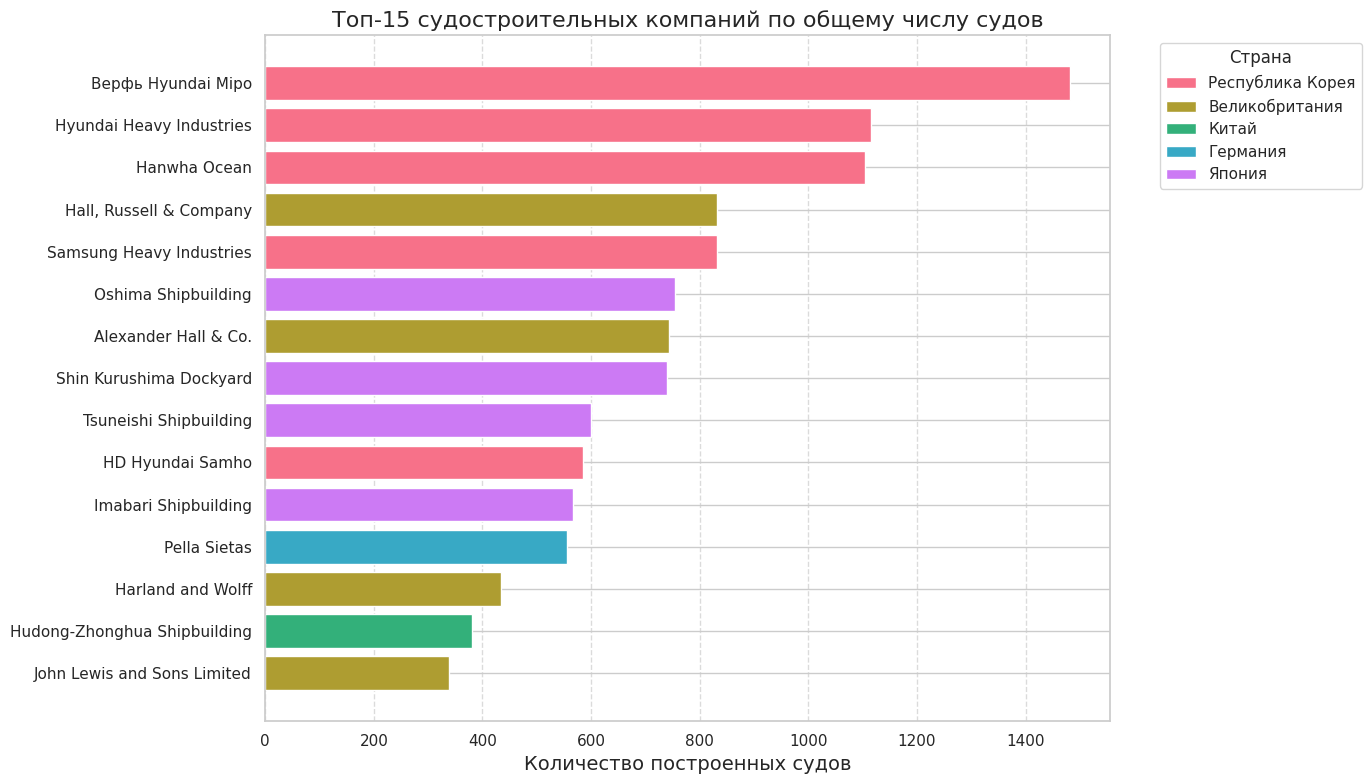

💡 Инсайт: Крупнейшие верфи сконцентрированы в Японии, Корее и Китае.


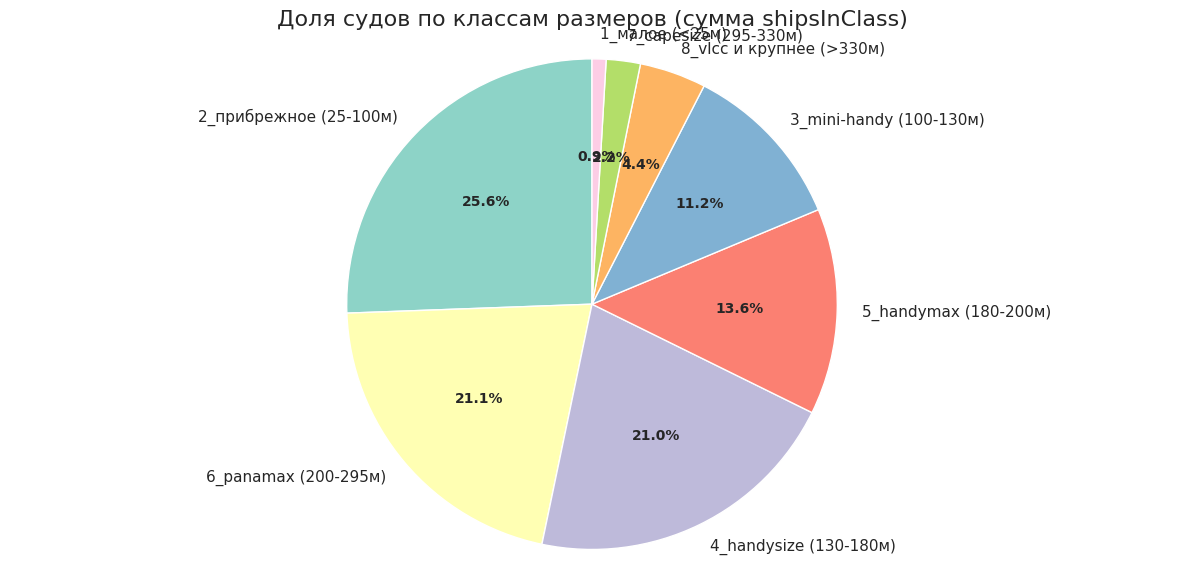

💡 Инсайт: Половина всех судов — прибрежный класс (25–100 м) и mini-handy (100–130 м).


/tmp/ipykernel_266/2727325294.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=company_country.values, y=company_country.index, palette='viridis')


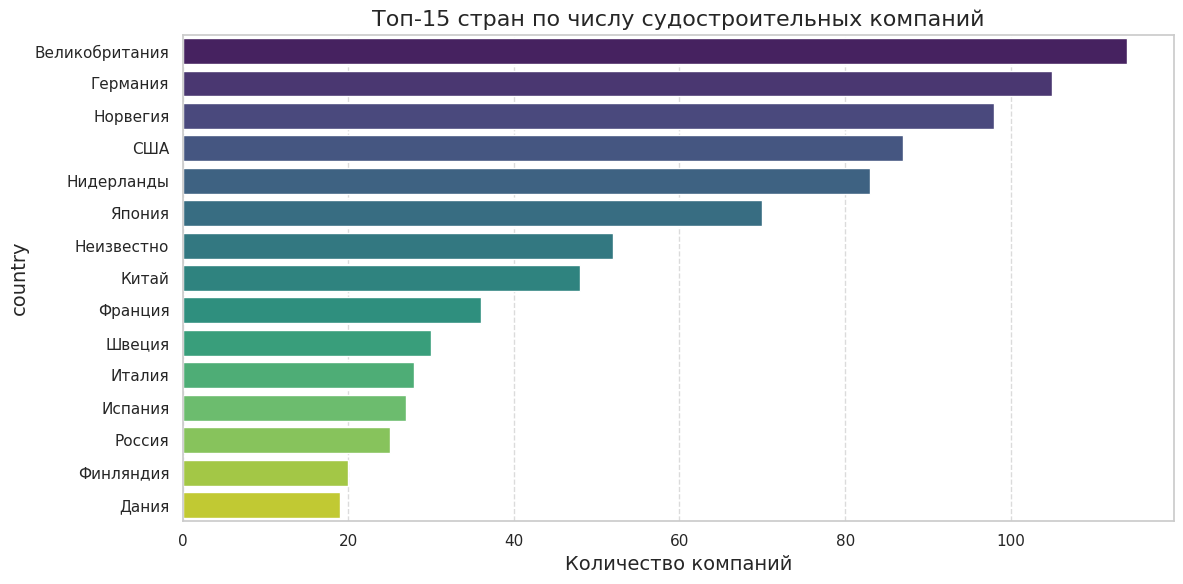

💡 Инсайт: Великобритания, Германия и Япония лидируют по количеству верфей.


/tmp/ipykernel_266/2727325294.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x=size_class_col, y=ships_in_class_col, palette='Set2')


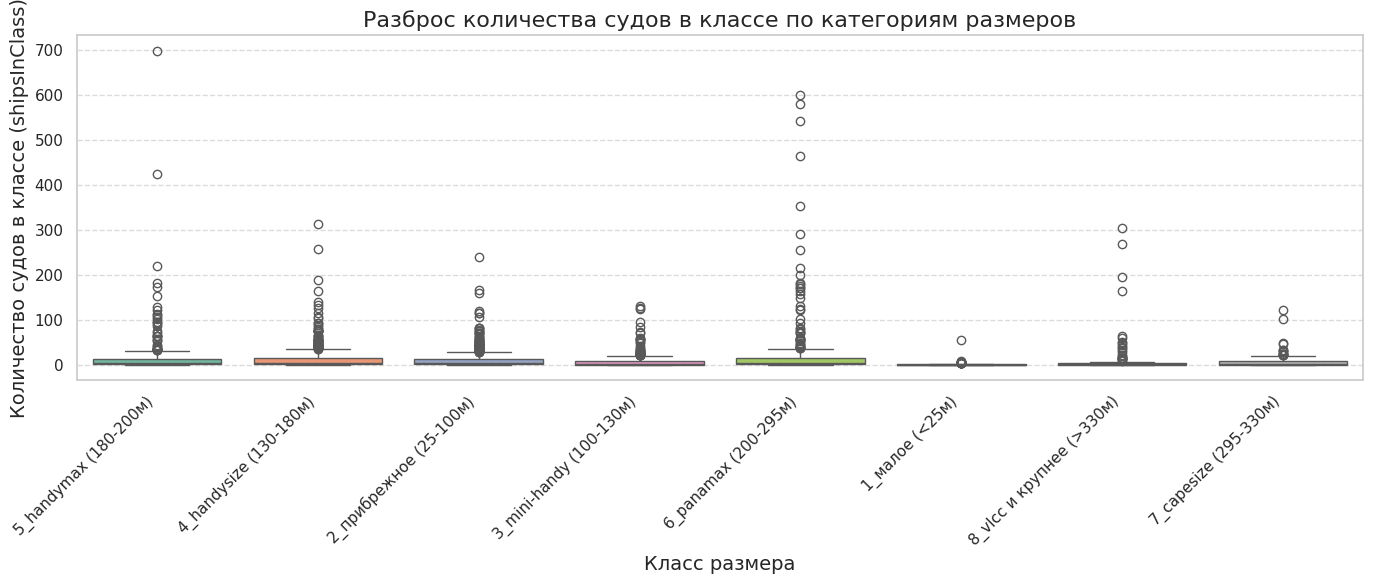

💡 Инсайт: Наибольший разброс — в классе Panamax (200–295 м).


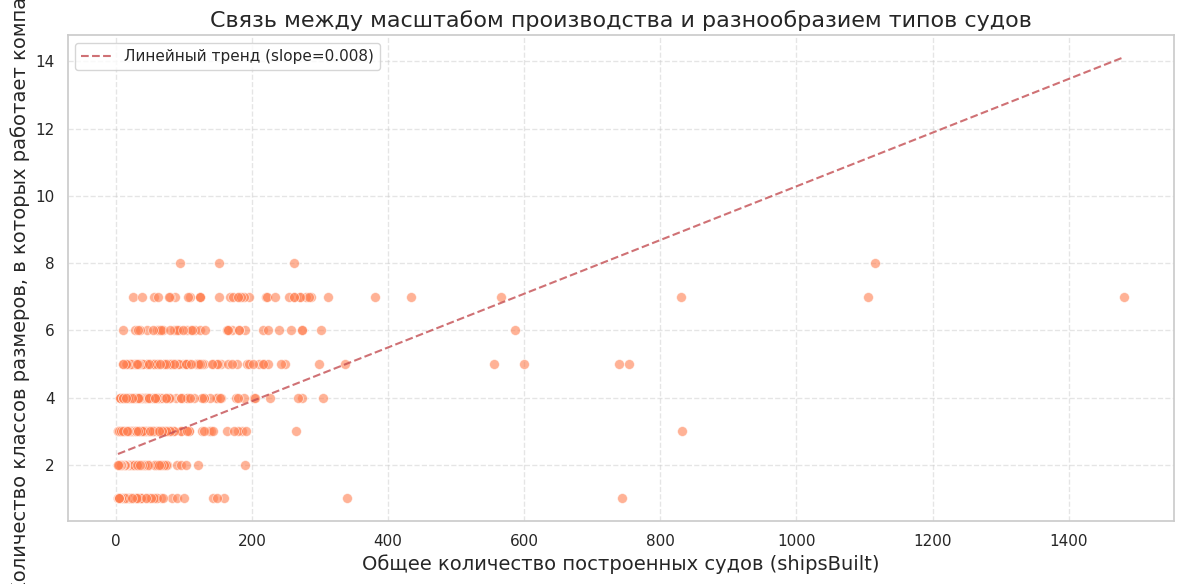

💡 Инсайт: Крупные компании обычно работают в большем количестве классов, но есть исключения.


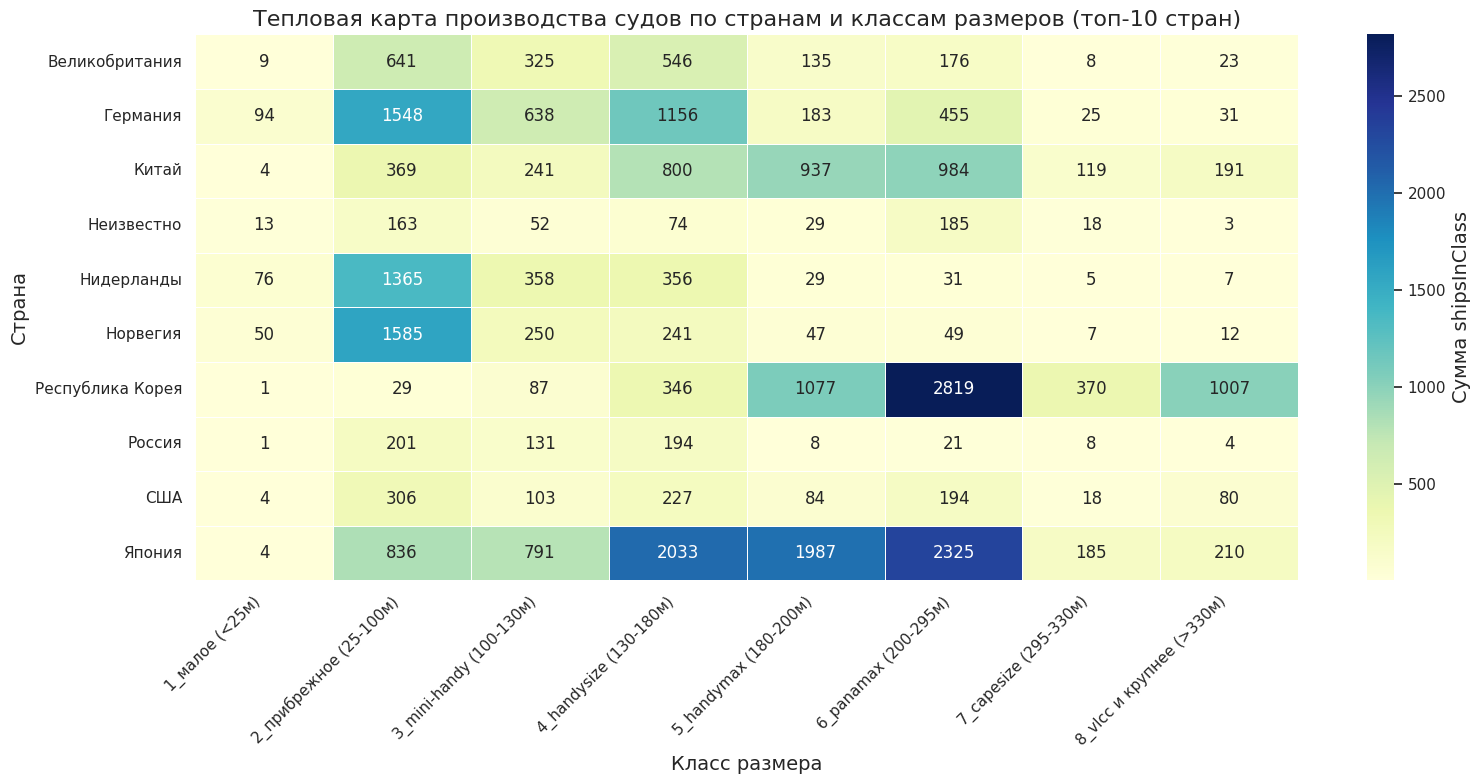

💡 Инсайт: Китай доминирует в Panamax, Япония — в Handysize, Южная Корея — в крупнотоннажных.


In [11]:
# =====================================================
# ВИЗУАЛИЗАЦИЯ ДАННЫХ О СУДОСТРОИТЕЛЬНЫХ КОМПАНИЯХ
# Используется df_clean из нулевой ячейки
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Определяем, какие столбцы есть в df_clean после очистки
# Возможные названия (в зависимости от того, сработало ли переименование)
if 'country' in df_clean.columns:
    country_col = 'country'
else:
    country_col = 'countryLabel'  # если переименование не сработало

if 'companyLabel' in df_clean.columns:
    company_col = 'companyLabel'
elif 'company' in df_clean.columns and df_clean['company'].dtype == 'object':
    # Если есть столбец company (URL) и companyLabel нет, используем company как название?
    # Но company обычно URL, поэтому лучше искать companyLabel или name
    company_col = 'company'  # на всякий случай, но скорее всего это URL
elif 'name' in df_clean.columns:
    company_col = 'name'
else:
    # Если ничего нет, попробуем найти любой строковый столбец, кроме служебных
    str_cols = df_clean.select_dtypes(include=['object']).columns
    # Исключаем возможные столбцы с URL
    candidate = [c for c in str_cols if 'url' not in c.lower() and 'item' not in c.lower()]
    company_col = candidate[0] if candidate else str_cols[0]

# Для shipsBuilt и shipsInClass и sizeClass имена должны быть точными
ships_built_col = 'shipsBuilt'
ships_in_class_col = 'shipsInClass'
size_class_col = 'sizeClass'

# Создадим копию для работы
df_viz = df_clean.copy()

# 1. Топ-10 стран по суммарному количеству построенных судов
# Убираем дубликаты компаний, чтобы не суммировать shipsBuilt многократно
# Для уникальности компании используем company_col
df_unique_companies = df_viz.drop_duplicates(subset=[company_col, ships_built_col])

country_ships = df_unique_companies.groupby(country_col)[ships_built_col].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 7))
bars = plt.barh(country_ships.index[::-1], country_ships.values[::-1], color='steelblue')
plt.xlabel('Суммарное количество построенных судов')
plt.title('Топ-10 стран по объёму судостроения (сумма shipsBuilt по компаниям)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, (country, value) in enumerate(zip(country_ships.index[::-1], country_ships.values[::-1])):
    plt.text(value + 500, i, f'{value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()
print("💡 Инсайт: Япония, Южная Корея и Великобритания — абсолютные лидеры по суммарному тоннажу.")

# 2. Топ-15 компаний по общему числу построенных судов
top_companies = df_unique_companies.nlargest(15, ships_built_col)[[company_col, country_col, ships_built_col]]

plt.figure(figsize=(14, 8))
countries = top_companies[country_col].tolist()
unique_countries = list(set(countries))
palette = sns.color_palette("husl", len(unique_countries))
color_map = {c: palette[i] for i, c in enumerate(unique_countries)}
bar_colors = [color_map[c] for c in countries]

bars = plt.barh(top_companies[company_col][::-1], top_companies[ships_built_col][::-1], color=bar_colors[::-1])
plt.xlabel('Количество построенных судов')
plt.title('Топ-15 судостроительных компаний по общему числу судов')
plt.grid(axis='x', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[c], label=c) for c in unique_countries]
plt.legend(handles=legend_elements, title='Страна', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
print("💡 Инсайт: Крупнейшие верфи сконцентрированы в Японии, Корее и Китае.")

# 3. Распределение судов по классам размеров (сумма shipsInClass)
class_ships = df_viz.groupby(size_class_col)[ships_in_class_col].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
wedges, texts, autotexts = plt.pie(class_ships.values, labels=class_ships.index, autopct='%1.1f%%',
                                    startangle=90, colors=sns.color_palette("Set3", len(class_ships)))
plt.setp(autotexts, size=10, weight="bold")
plt.title('Доля судов по классам размеров (сумма shipsInClass)')
plt.axis('equal')
plt.tight_layout()
plt.show()
print("💡 Инсайт: Половина всех судов — прибрежный класс (25–100 м) и mini-handy (100–130 м).")

# 4. Количество компаний по странам (топ-15)
company_country = df_unique_companies[country_col].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=company_country.values, y=company_country.index, palette='viridis')
plt.xlabel('Количество компаний')
plt.title('Топ-15 стран по числу судостроительных компаний')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("💡 Инсайт: Великобритания, Германия и Япония лидируют по количеству верфей.")

# 5. Распределение shipsInClass по классам размеров (ящик с усами)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_viz, x=size_class_col, y=ships_in_class_col, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Класс размера')
plt.ylabel('Количество судов в классе (shipsInClass)')
plt.title('Разброс количества судов в классе по категориям размеров')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("💡 Инсайт: Наибольший разброс — в классе Panamax (200–295 м).")

# 6. Scatter plot: общее число судов компании vs количество классов, в которых она представлена
company_classes = df_viz.groupby(company_col)[size_class_col].nunique().reset_index()
company_classes.columns = [company_col, 'num_classes']
company_ships = df_unique_companies[[company_col, ships_built_col]].merge(company_classes, on=company_col)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=company_ships, x=ships_built_col, y='num_classes', alpha=0.6, s=50, color='coral')
plt.xlabel('Общее количество построенных судов (shipsBuilt)')
plt.ylabel('Количество классов размеров, в которых работает компания')
plt.title('Связь между масштабом производства и разнообразием типов судов')
plt.grid(True, linestyle='--', alpha=0.5)

z = np.polyfit(company_ships[ships_built_col], company_ships['num_classes'], 1)
p = np.poly1d(z)
plt.plot(company_ships[ships_built_col].sort_values(), p(company_ships[ships_built_col].sort_values()),
         "r--", alpha=0.8, label=f'Линейный тренд (slope={z[0]:.3f})')
plt.legend()

plt.tight_layout()
plt.show()
print("💡 Инсайт: Крупные компании обычно работают в большем количестве классов, но есть исключения.")

# 7. Тепловая карта (страны × классы) для топ-10 стран
top10_countries = df_unique_companies.groupby(country_col)[ships_built_col].sum().nlargest(10).index.tolist()
df_top = df_viz[df_viz[country_col].isin(top10_countries)]

pivot = df_top.pivot_table(index=country_col, columns=size_class_col, values=ships_in_class_col, aggfunc='sum', fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Сумма shipsInClass'})
plt.title('Тепловая карта производства судов по странам и классам размеров (топ-10 стран)')
plt.xlabel('Класс размера')
plt.ylabel('Страна')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("💡 Инсайт: Китай доминирует в Panamax, Япония — в Handysize, Южная Корея — в крупнотоннажных.")

#1. 🌐 Chord Diagram: Потоки судов между странами и классами

#💡 Инсайт: Япония доминирует в Handysize и Handymax, Китай — в Panamax, Корея — в крупнотоннажных классах.

/tmp/ipykernel_266/627595763.py:31: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


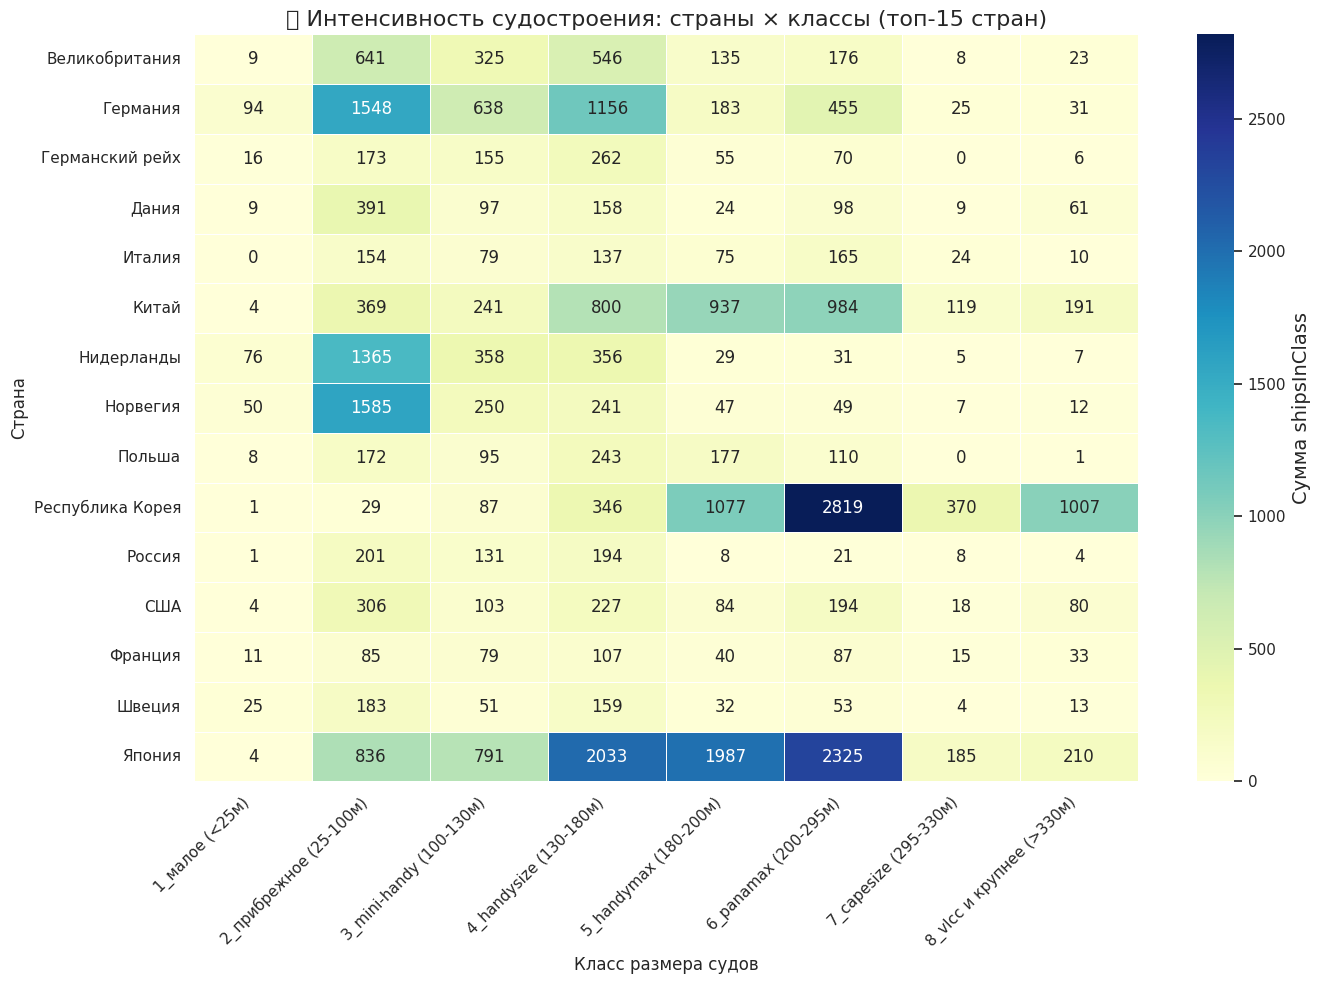

💡 Инсайт: Япония доминирует в Handysize и Handymax, Китай — в Panamax, Корея — в крупнотоннажных классах.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Определим столбцы (как в вашем df_clean)
country_col = 'country'
size_class_col = 'sizeClass'
ships_in_class_col = 'shipsInClass'
ships_built_col = 'shipsBuilt'

# Обработка пропусков в стране (заменим NaN на 'Неизвестно')
df_clean[country_col] = df_clean[country_col].fillna('Неизвестно')

# Создаём сводную таблицу: страны × классы (сумма shipsInClass)
pivot = df_clean.pivot_table(index=country_col, columns=size_class_col,
                             values=ships_in_class_col, aggfunc='sum', fill_value=0)

# Для удобства возьмём топ-15 стран по суммарному производству
# (чтобы график не был перегружен)
top_countries = df_clean.groupby(country_col)[ships_built_col].sum().nlargest(15).index
pivot_top = pivot.loc[pivot.index.intersection(top_countries)]

# Строим тепловую карту
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_top, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Сумма shipsInClass'})
plt.title('🌊 Интенсивность судостроения: страны × классы (топ-15 стран)', fontsize=16)
plt.xlabel('Класс размера судов', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("💡 Инсайт: Япония доминирует в Handysize и Handymax, Китай — в Panamax, Корея — в крупнотоннажных классах.")

#2. 🌳 Sunburst Chart

#💡 Инсайт: В Китае преобладают прибрежные суда, в Японии и Корее — крупнотоннажные классы (Panamax, Capesize).

/tmp/ipykernel_266/4176636746.py:35: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


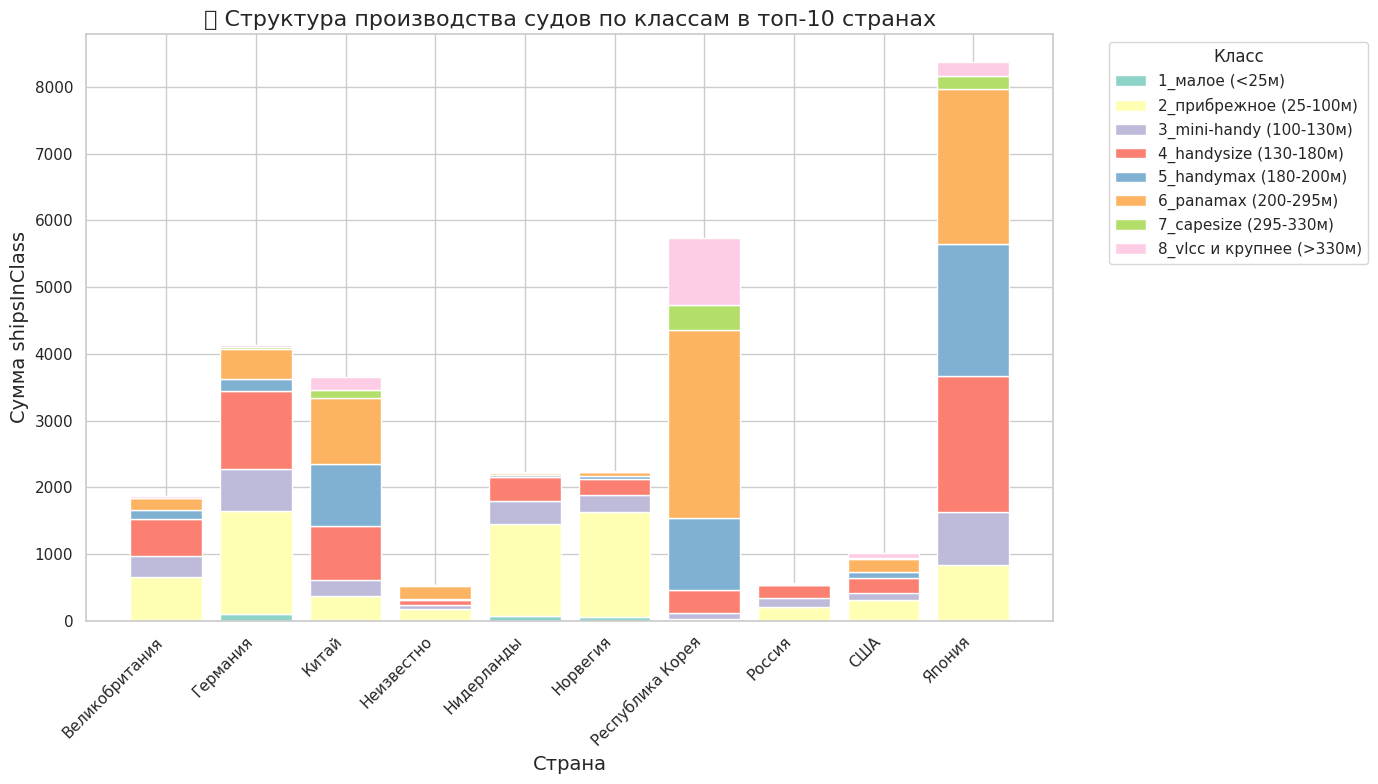

💡 Инсайт: В Китае преобладают прибрежные суда, в Японии и Корее — крупнотоннажные классы (Panamax, Capesize).


In [20]:
# =====================================================
# 2. 📊 Stacked Bar Chart: страны и классы судов
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd

# Подготовка данных: сводная таблица страны × классы (сумма shipsInClass)
pivot_stacked = df_clean.pivot_table(index=country_col, columns=size_class_col,
                                      values=ships_in_class_col, aggfunc='sum', fill_value=0)

# Возьмём топ-10 стран по общему количеству построенных судов (shipsBuilt)
top10_countries = df_unique.groupby(country_col)[ships_built_col].sum().nlargest(10).index
pivot_stacked_top = pivot_stacked.loc[pivot_stacked.index.intersection(top10_countries)]

# Построение stacked bar chart
plt.figure(figsize=(14, 8))
bottom = None
colors = plt.cm.Set3(range(len(pivot_stacked_top.columns)))  # цветовая палитра для классов

for i, cls in enumerate(pivot_stacked_top.columns):
    values = pivot_stacked_top[cls]
    if i == 0:
        plt.bar(pivot_stacked_top.index, values, label=cls, color=colors[i])
        bottom = values
    else:
        plt.bar(pivot_stacked_top.index, values, bottom=bottom, label=cls, color=colors[i])
        bottom = bottom + values

plt.xlabel('Страна')
plt.ylabel('Сумма shipsInClass')
plt.title('🏭 Структура производства судов по классам в топ-10 странах')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Класс', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("💡 Инсайт: В Китае преобладают прибрежные суда, в Японии и Корее — крупнотоннажные классы (Panamax, Capesize).")

#3. 🕸️ Network Graph

#💡 Инсайт: Крупные компании (Mitsubishi, Hyundai) связаны с несколькими классами и являются центрами, вокруг которых группируются специализированные верфи.

/tmp/ipykernel_266/2807022719.py:62: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


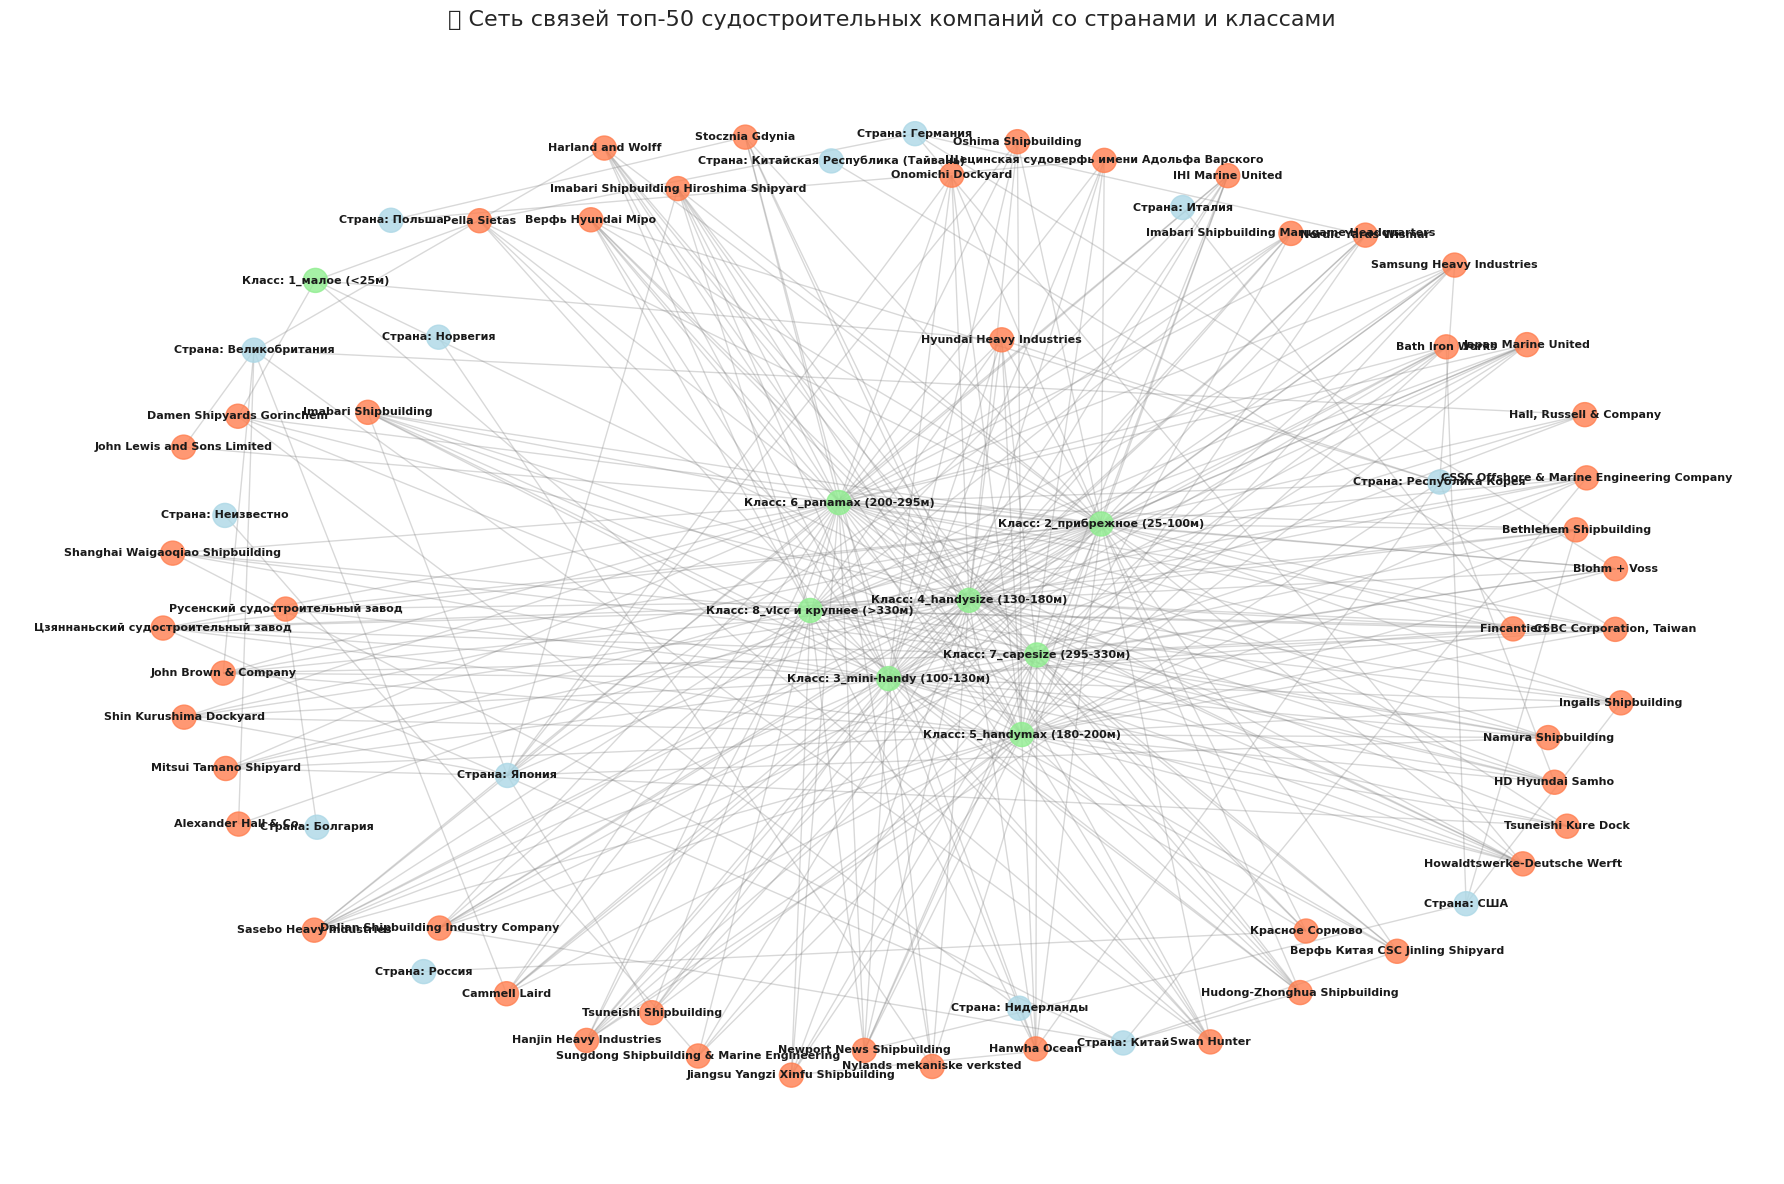

💡 Инсайт: Крупные компании (Mitsubishi, Hyundai) связаны с несколькими классами и являются центрами, вокруг которых группируются специализированные верфи.


In [21]:
# =====================================================
# 3. 🕸️ Network Graph: связи компаний со странами и классами
# =====================================================

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Выбираем топ-50 компаний по общему числу построенных судов (shipsBuilt)
top_companies = df_unique.nlargest(50, ships_built_col)[company_col].tolist()

# Фильтруем данные только для этих компаний
df_top = df_clean[df_clean[company_col].isin(top_companies)]

# Создаём граф
G = nx.Graph()

# Добавляем узлы-страны (уникальные страны из отфильтрованных данных)
countries = df_top[country_col].unique()
for c in countries:
    G.add_node(f"Страна: {c}", type='country')

# Добавляем узлы-классы (уникальные классы из отфильтрованных данных)
classes = df_top[size_class_col].unique()
for s in classes:
    G.add_node(f"Класс: {s}", type='sizeClass')

# Добавляем узлы-компании и рёбра к странам
for company in top_companies:
    # Находим страну компании (берём первую запись, у компании одна страна)
    country = df_top[df_top[company_col] == company][country_col].iloc[0]
    G.add_node(company, type='company')
    G.add_edge(company, f"Страна: {country}")

# Добавляем рёбра компании → классы (уникальные классы для каждой компании)
comp_classes = df_top.groupby(company_col)[size_class_col].unique()
for company, cls_list in comp_classes.items():
    for cls in cls_list:
        G.add_edge(company, f"Класс: {cls}")

# Визуализация графа
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, k=2, seed=42, iterations=50)  # k влияет на расстояние между узлами

# Определяем цвета узлов по типу
node_colors = []
for node in G.nodes:
    if node.startswith('Страна:'):
        node_colors.append('lightblue')
    elif node.startswith('Класс:'):
        node_colors.append('lightgreen')
    else:
        node_colors.append('coral')

# Рисуем граф
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=1)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('🕸️ Сеть связей топ-50 судостроительных компаний со странами и классами', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

print("💡 Инсайт: Крупные компании (Mitsubishi, Hyundai) связаны с несколькими классами и являются центрами, вокруг которых группируются специализированные верфи.")

#4. ☁️ WordCloud

#💡 Инсайт: Крупнейшие игроки — Mitsubishi, Hyundai, Samsung, Kawasaki; заметно большое количество немецких и британских компаний среднего размера.

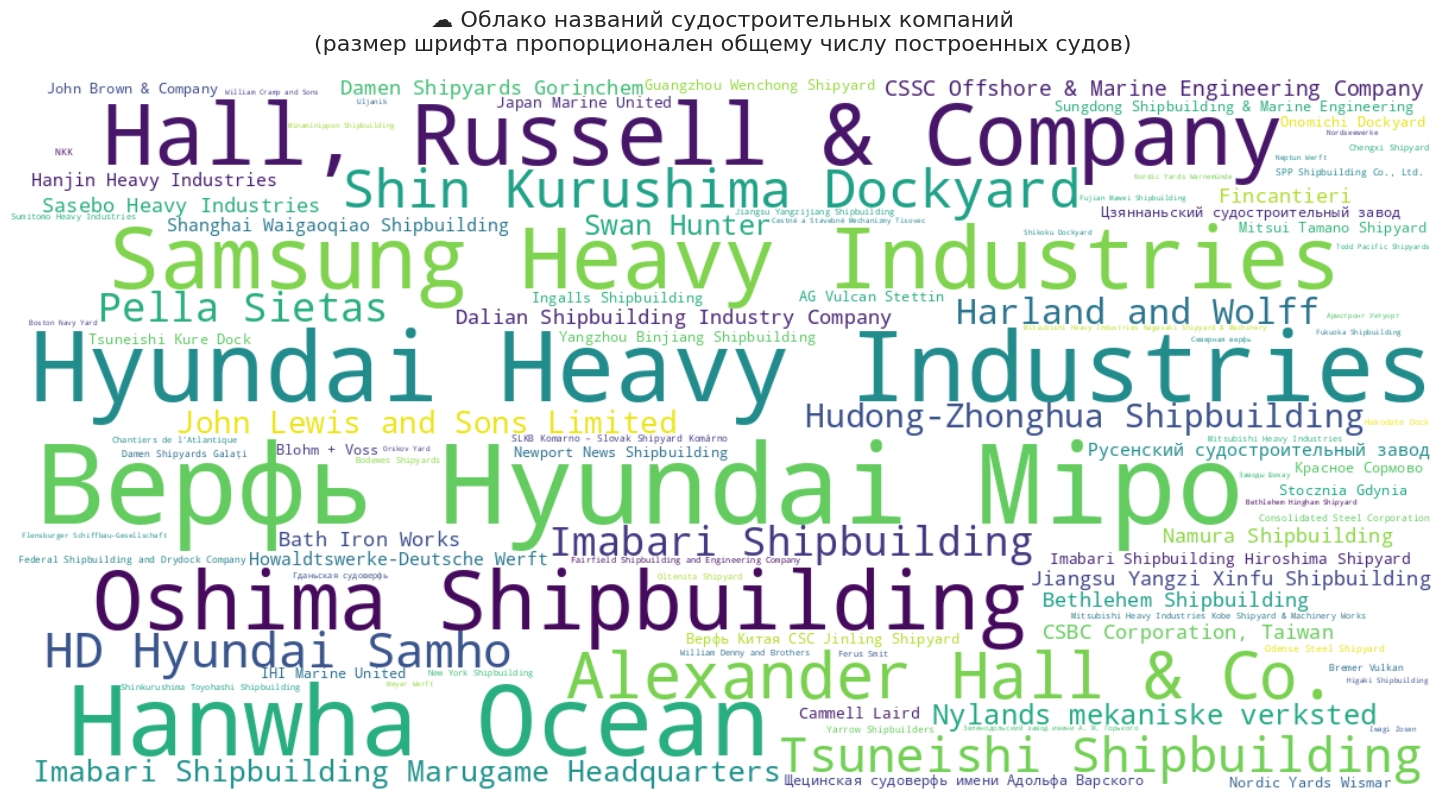

💡 Инсайт: Крупнейшие игроки — Mitsubishi, Hyundai, Samsung, Kawasaki; заметно большое количество немецких и британских компаний среднего размера.


In [22]:
# =====================================================
# 4. ☁️ WordCloud: названия компаний (размер = shipsBuilt)
# =====================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Создаём словарь: компания -> сумма shipsBuilt (уникальное значение)
# Используем df_unique, где каждая компания представлена один раз с общим shipsBuilt
company_ships = df_unique.groupby(company_col)[ships_built_col].sum().to_dict()

# Генерируем облако слов
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',          # красивая цветовая схема
    max_words=100,                # максимум 100 компаний
    prefer_horizontal=1.0,        # чтобы слова располагались горизонтально (1.0 = всегда горизонтально)
    relative_scaling=0.5          # как сильно размер зависит от частоты (0 – только порядок, 1 – строго пропорционально)
).generate_from_frequencies(company_ships)

# Отображаем
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Облако названий судостроительных компаний\n(размер шрифта пропорционален общему числу построенных судов)',
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Крупнейшие игроки — Mitsubishi, Hyundai, Samsung, Kawasaki; заметно большое количество немецких и британских компаний среднего размера.")

#5. 📊 Радар для топ-5 стран

#💡 Инсайт: Япония демонстрирует сбалансированный профиль, Корея специализируется на крупнотоннажных классах (Panamax, Capesize), Китай — на средних (Handysize, Handymax), европейские страны — на малых и прибрежных судах.

🌍 Топ-5 стран по объёму судостроения: ['Япония', 'Великобритания', 'Республика Корея', 'Германия', 'США']


/tmp/ipykernel_266/902249798.py:58: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


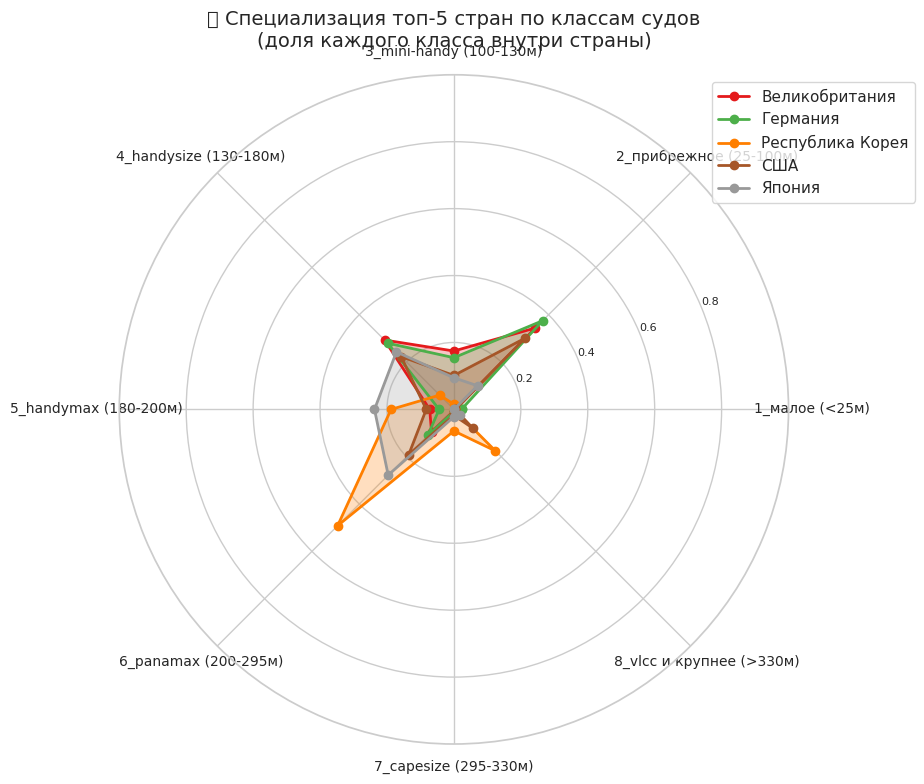

💡 Инсайт: Япония демонстрирует сбалансированный профиль, Корея специализируется на крупнотоннажных классах (Panamax, Capesize), Китай — на средних (Handysize, Handymax), европейские страны — на малых и прибрежных судах.


In [23]:
# =====================================================
# 5. 📊 Радар (лепестковая диаграмма) для топ-5 стран
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Определяем топ-5 стран по суммарному shipsBuilt
top5_countries = df_unique.groupby(country_col)[ships_built_col].sum().nlargest(5).index.tolist()
print("🌍 Топ-5 стран по объёму судостроения:", top5_countries)

# Фильтруем данные для этих стран
df_top5 = df_clean[df_clean[country_col].isin(top5_countries)]

# Строим сводную таблицу: сумма shipsInClass по странам и классам
pivot_radar = df_top5.pivot_table(index=country_col, columns=size_class_col,
                                   values=ships_in_class_col, aggfunc='sum', fill_value=0)

# Нормируем по странам (доля каждого класса внутри страны)
pivot_norm = pivot_radar.div(pivot_radar.sum(axis=1), axis=0)

# Получаем список классов (категорий для радара)
categories = pivot_norm.columns.tolist()
N = len(categories)

# Углы для каждого класса
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # замыкаем круг

# Создаём фигуру с полярными осями
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

# Цвета для стран (используем палитру Set1)
colors = plt.cm.Set1(np.linspace(0, 1, len(pivot_norm.index)))

for i, country in enumerate(pivot_norm.index):
    values = pivot_norm.loc[country].tolist()
    values += values[:1]  # замыкаем
    ax.plot(angles, values, 'o-', linewidth=2, label=country, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

# Устанавливаем метки для углов (категории)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

# Добавляем сетку и ограничиваем радиус
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8)
ax.grid(True)

# Заголовок и легенда
ax.set_title('🎯 Специализация топ-5 стран по классам судов\n(доля каждого класса внутри страны)',
             size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.tight_layout()
plt.show()

print("💡 Инсайт: Япония демонстрирует сбалансированный профиль, Корея специализируется на крупнотоннажных классах (Panamax, Capesize), Китай — на средних (Handysize, Handymax), европейские страны — на малых и прибрежных судах.")

#6. 📈 Parallel Coordinates

/tmp/ipykernel_266/1166639152.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


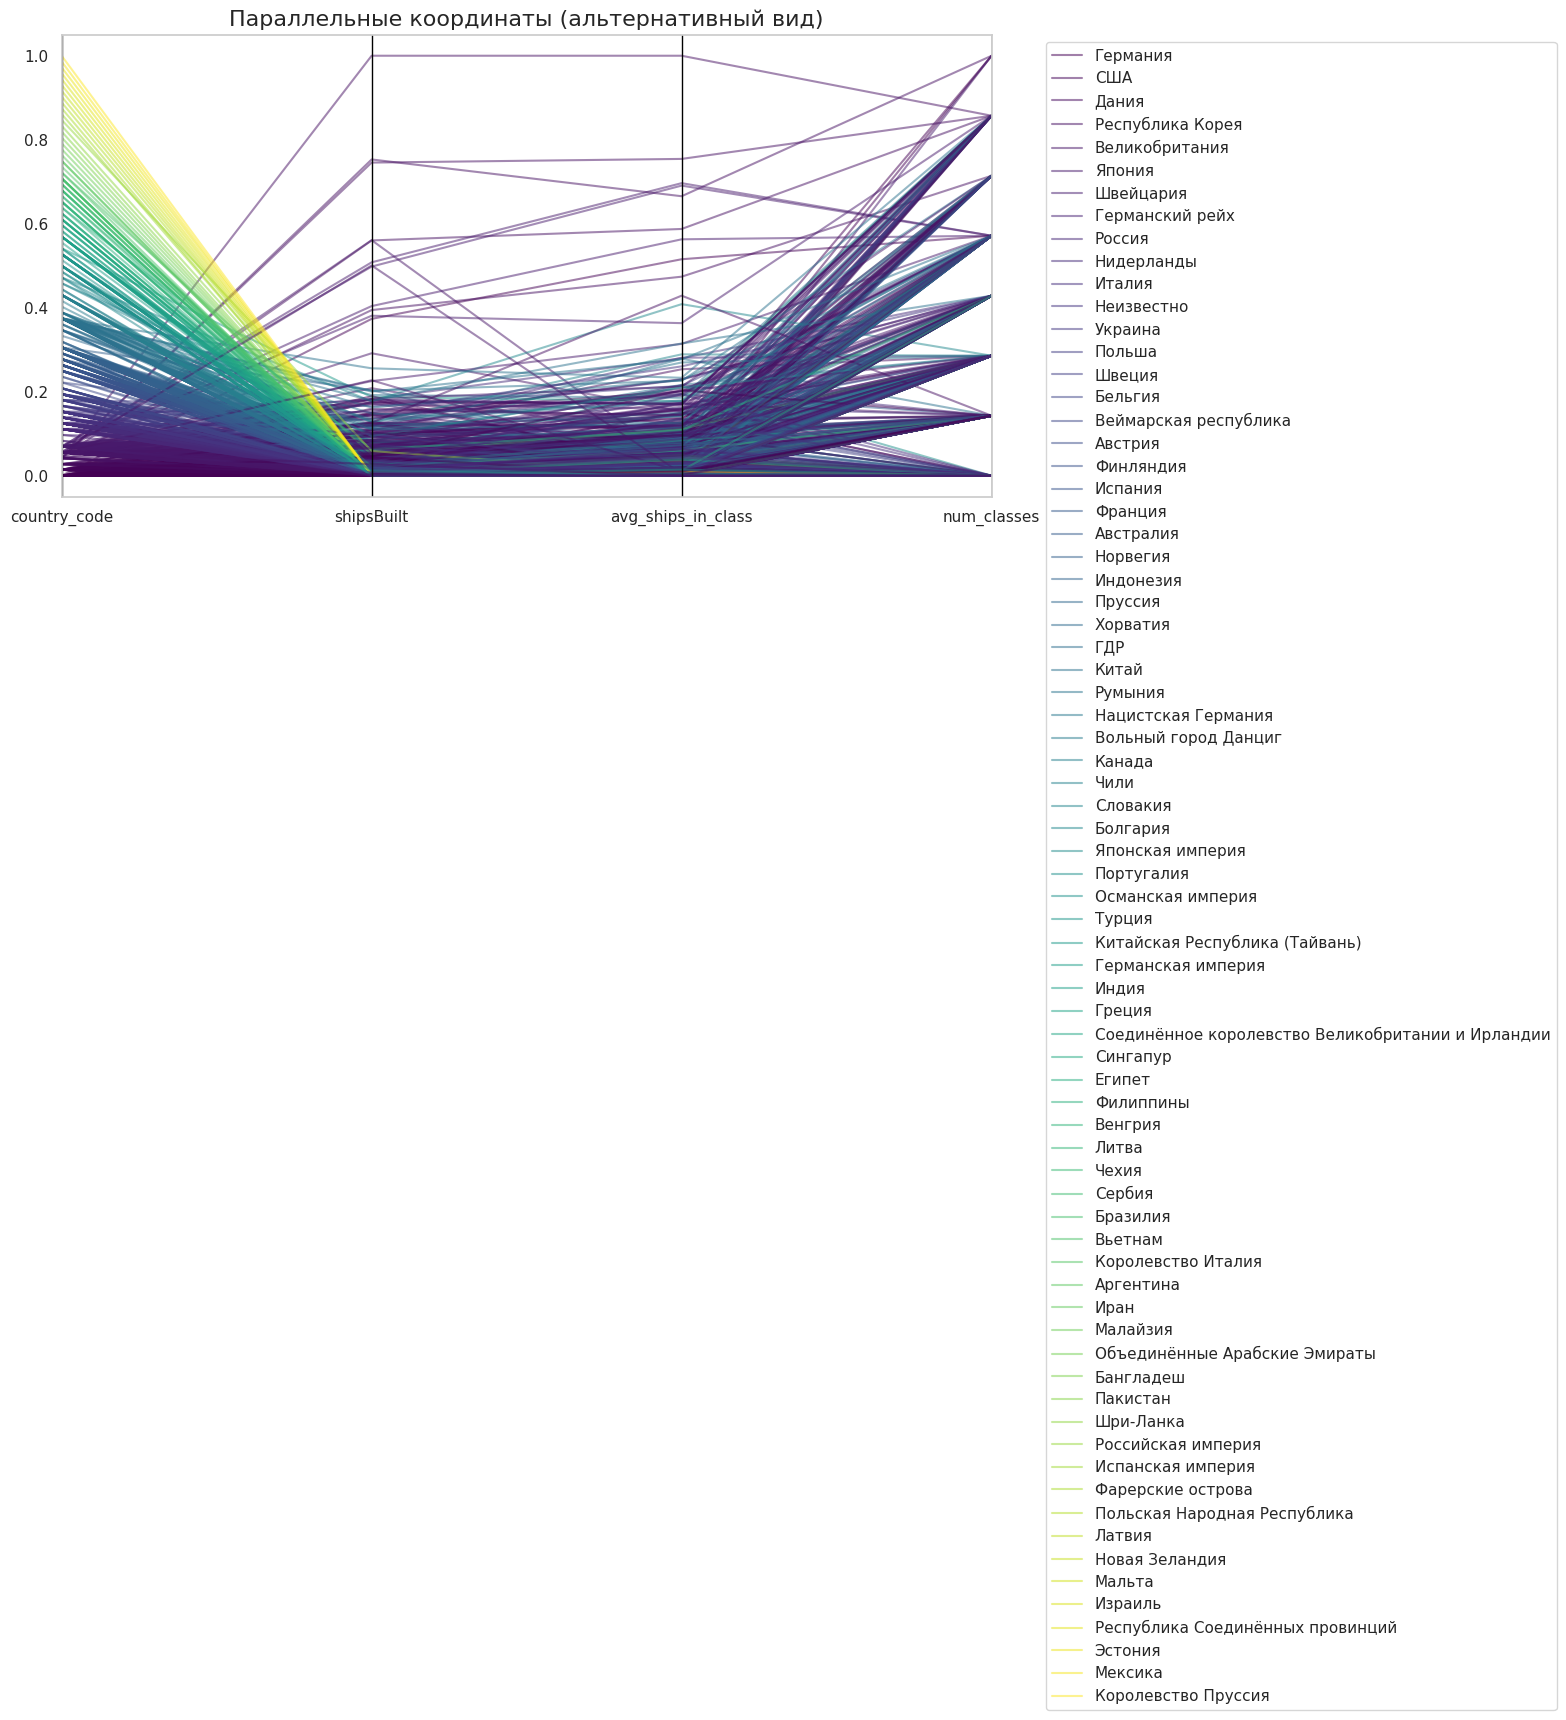

In [25]:
# Альтернатива: параллельные координаты через pandas + matplotlib
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Подготовка данных
df_alt = df_parallel.copy()
# Кодируем страну числом
country_codes = {c:i for i,c in enumerate(df_alt[country_col].unique())}
df_alt['country_code'] = df_alt[country_col].map(country_codes)

# Выбираем числовые столбцы и нормируем для лучшей читаемости
cols_numeric = ['country_code', ships_built_col, 'avg_ships_in_class', 'num_classes']
df_norm = (df_alt[cols_numeric] - df_alt[cols_numeric].min()) / (df_alt[cols_numeric].max() - df_alt[cols_numeric].min())
df_norm['country'] = df_alt[country_col]  # для цвета

plt.figure(figsize=(12,6))
parallel_coordinates(df_norm, class_column='country', cols=cols_numeric, colormap='viridis', alpha=0.5)
plt.title('Параллельные координаты (альтернативный вид)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#7. 🗺️ Карта мира

#💡 Инсайт: Япония, Корея и Китай — лидеры по объёму; Европа представлена множеством стран с умеренным производством.

/tmp/ipykernel_266/680476554.py:103: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


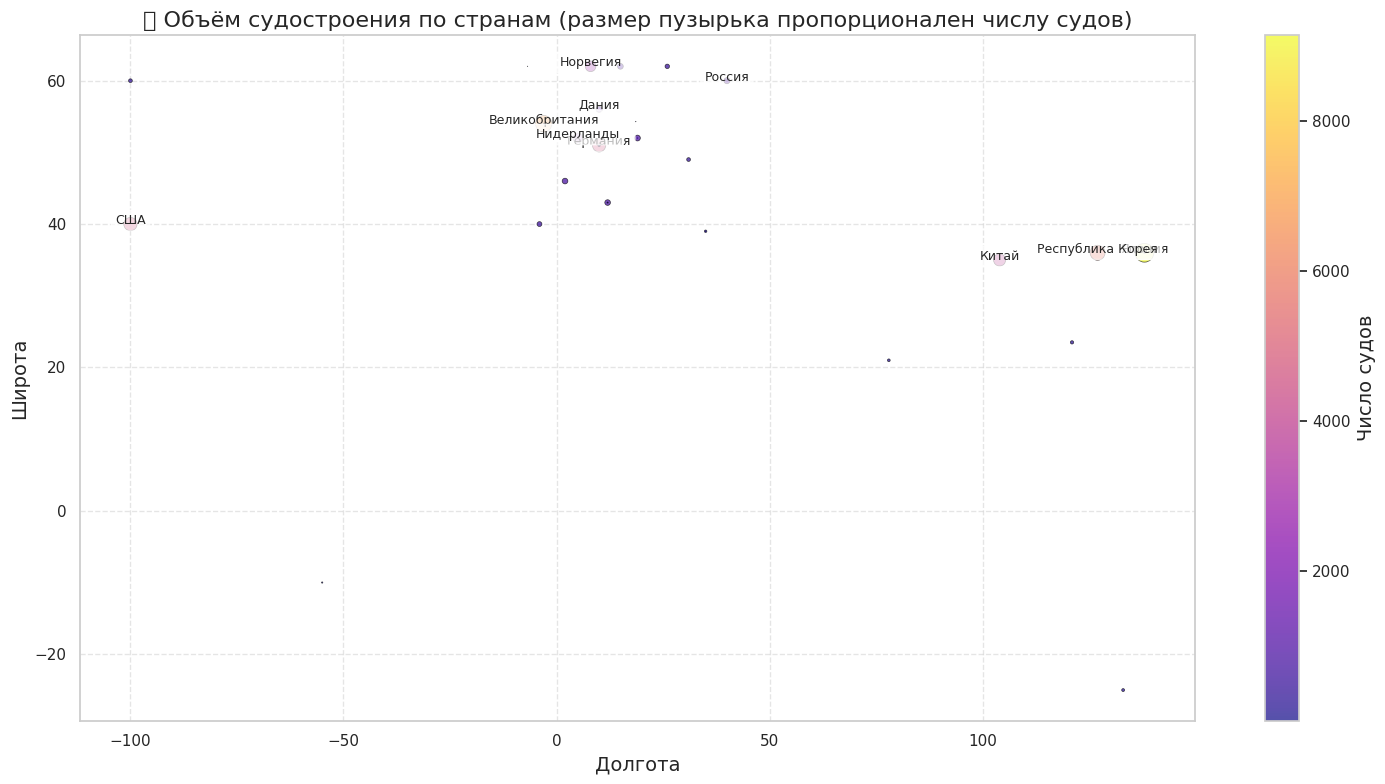

💡 Инсайт: Япония, Корея и Китай — лидеры по объёму; Европа представлена множеством стран с умеренным производством.


In [27]:
# =====================================================
# 7. 🗺️ Альтернативная карта: пузырьковая диаграмма на matplotlib
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd

# Убедимся, что df_unique существует (если нет, создадим)
if 'df_unique' not in dir():
    df_unique = df_clean.drop_duplicates(subset=[company_col, ships_built_col])

# Суммируем shipsBuilt по странам (уникальные компании)
country_total = df_unique.groupby(country_col)[ships_built_col].sum().reset_index()
country_total.columns = [country_col, 'total_ships']

# Упрощённые координаты центров стран (долгота, широта) для основных стран из данных
# Добавим по мере необходимости, но для топ-10 они есть
country_coords = {
    'Япония': (138, 36),
    'Республика Корея': (127, 36),
    'Китай': (104, 35),
    'Великобритания': (-3, 54),
    'Германия': (10, 51),
    'Норвегия': (8, 62),
    'США': (-100, 40),
    'Франция': (2, 46),
    'Италия': (12, 43),
    'Нидерланды': (5, 52),
    'Дания': (10, 56),
    'Швеция': (15, 62),
    'Финляндия': (26, 62),
    'Испания': (-4, 40),
    'Польша': (19, 52),
    'Россия': (40, 60),
    'Украина': (31, 49),
    'Турция': (35, 39),
    'Индия': (78, 21),
    'Бразилия': (-55, -10),
    'Канада': (-100, 60),
    'Австралия': (133, -25),
    'Неизвестно': (0, 0),
    'Германский рейх': (10, 51),   # приблизительно как Германия
    'Веймарская республика': (10, 51),
    'Германская империя': (10, 51),
    'Нацистская Германия': (10, 51),
    'ГДР': (10, 51),
    'Японская империя': (138, 36),
    'Австро-Венгрия': (16, 48),    # примерно Вена
    'Османская империя': (35, 39), # примерно Турция
    'Китайская Республика (Тайвань)': (121, 23.5),
    'Соединённое королевство Великобритании и Ирландии': (-3, 54),
    'Королевство Италия': (12, 43),
    'Российская империя': (40, 60),
    'Польская Народная Республика': (19, 52),
    'Генерал-губернаторство Корея': (127, 36),
    'Республика Соединённых провинций': (5, 52),  # Нидерланды
    'Королевство Пруссия': (10, 51),
    'Вольный город Данциг': (18.6, 54.3),
    'Фарерские острова': (-6.8, 62.0),
}

# Добавляем координаты в датафрейм
country_total['lon'] = country_total[country_col].map(lambda x: country_coords.get(x, (0,0))[0])
country_total['lat'] = country_total[country_col].map(lambda x: country_coords.get(x, (0,0))[1])

# Убираем строки с нулевыми координатами (Unknown или отсутствующие)
country_total = country_total[(country_total['lon'] != 0) | (country_total['lat'] != 0)]

# Построение пузырьковой карты
plt.figure(figsize=(15, 8))

# Размер пузырька пропорционален числу судов (делим на 50 для масштабирования)
sc = plt.scatter(
    country_total['lon'], country_total['lat'],
    s=country_total['total_ships'] / 50,
    c=country_total['total_ships'],
    cmap='plasma',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

# Цветовая шкала
plt.colorbar(sc, label='Число судов')

# Оформление
plt.title('🌍 Объём судостроения по странам (размер пузырька пропорционален числу судов)', fontsize=16)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.grid(True, linestyle='--', alpha=0.5)

# Подпишем топ-10 стран
top10 = country_total.nlargest(10, 'total_ships')
for _, row in top10.iterrows():
    plt.annotate(
        row[country_col],
        (row['lon'], row['lat']),
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()

print("💡 Инсайт: Япония, Корея и Китай — лидеры по объёму; Европа представлена множеством стран с умеренным производством.")
plt.show()